<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Feed-Forward Networks</h1>
<p>This section is basically a continuation of the ANN section.</p>
<h2>MNIST dataset</h2>
<p>The MNSIT dataset is a lot of hard-written digits, one of the most famous ML datasets.</p>
</div>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as khg

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


In [2]:
path = khg.dataset_download("oddrationale/mnist-in-csv", output_dir='../../assets/mnist')
path

'../../assets/mnist'

In [3]:
testData = np.loadtxt('../../assets/mnist/mnist_test.csv', delimiter=',', dtype=str)
trainData = np.loadtxt('../../assets/mnist/mnist_train.csv', delimiter=',', dtype=str)

print(trainData.shape)
print(testData.shape)

trainData

(60001, 785)
(10001, 785)


array([['label', '1x1', '1x2', ..., '28x26', '28x27', '28x28'],
       ['5', '0', '0', ..., '0', '0', '0'],
       ['0', '0', '0', ..., '0', '0', '0'],
       ...,
       ['5', '0', '0', ..., '0', '0', '0'],
       ['6', '0', '0', ..., '0', '0', '0'],
       ['8', '0', '0', ..., '0', '0', '0']],
      shape=(60001, 785), dtype='<U5')

In [4]:
trainLabels = np.array(trainData[1:,0], dtype=float)
trainData = np.array(trainData[1:,1:], dtype=float)

print(trainData.shape)
print(trainLabels.shape)
trainLabels

(60000, 784)
(60000,)


array([5., 0., 4., ..., 5., 6., 8.], shape=(60000,))

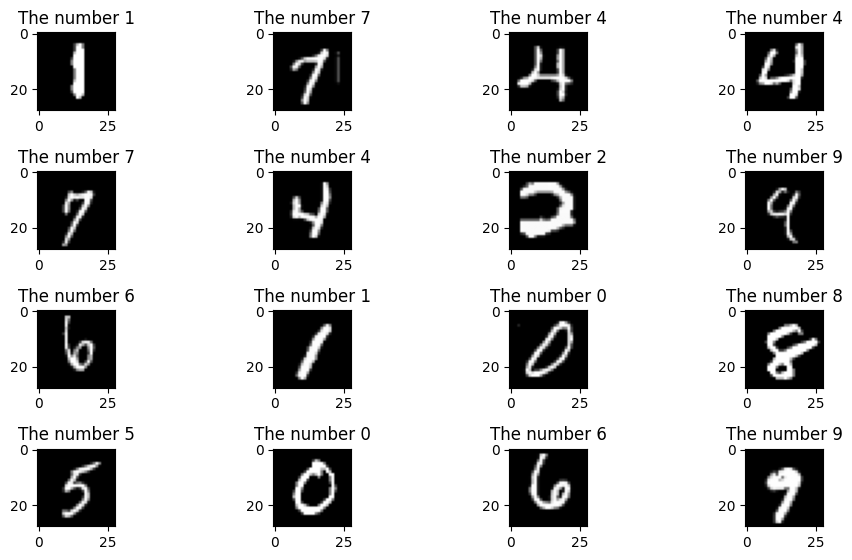

In [5]:
def plotSample(digit: int = None):
    fig, axs = plt.subplots(4, 4, figsize=(10, 6))

    if digit != None:
        data = trainData[np.where(trainLabels == digit)]
        label = trainLabels[np.where(trainLabels == digit)]
    else:
        data = trainData
        label = trainLabels

    for ax in axs.flatten():
        randimImageToShow = np.random.randint(0, data.shape[0])
        img = np.reshape(data[randimImageToShow], (28, 28))
        ax.imshow(img, cmap='gray')

        ax.set_title('The number %i'%label[randimImageToShow])

    plt.tight_layout(rect=[0,0,1,.95])
    plt.show()

plotSample()

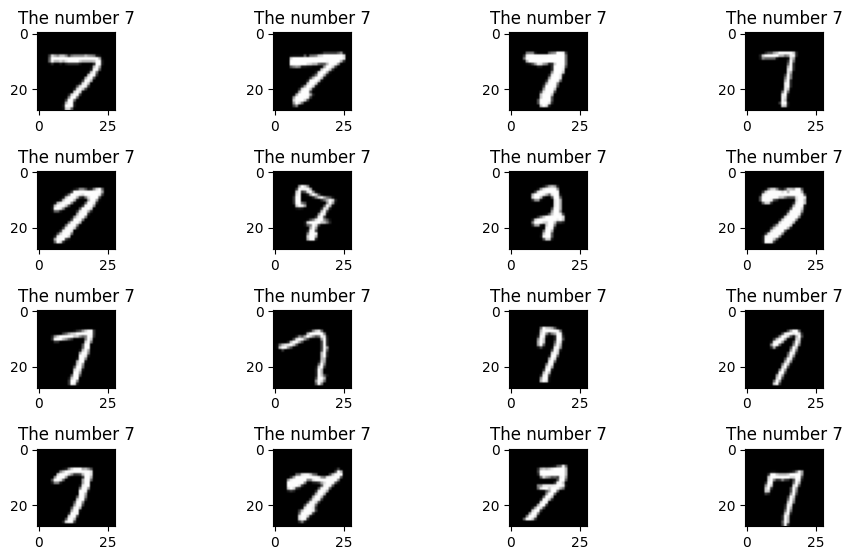

In [6]:
plotSample(7)

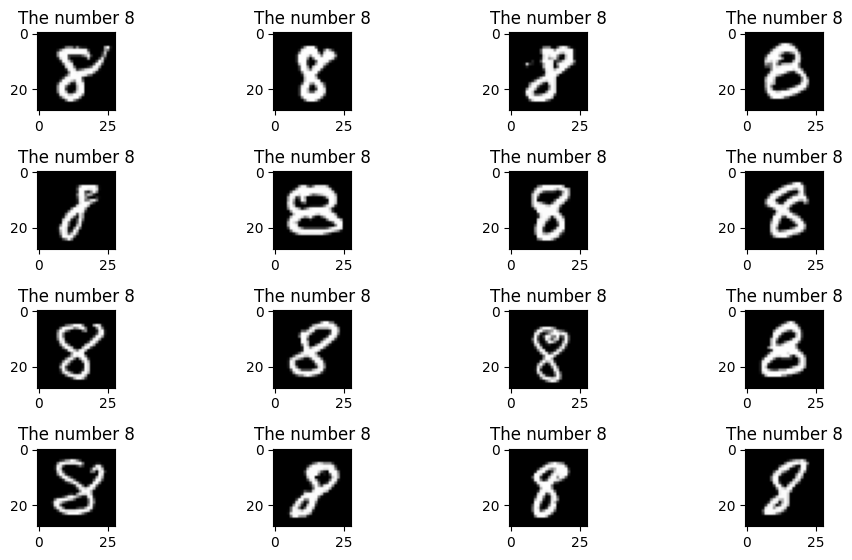

In [7]:
plotSample(8)

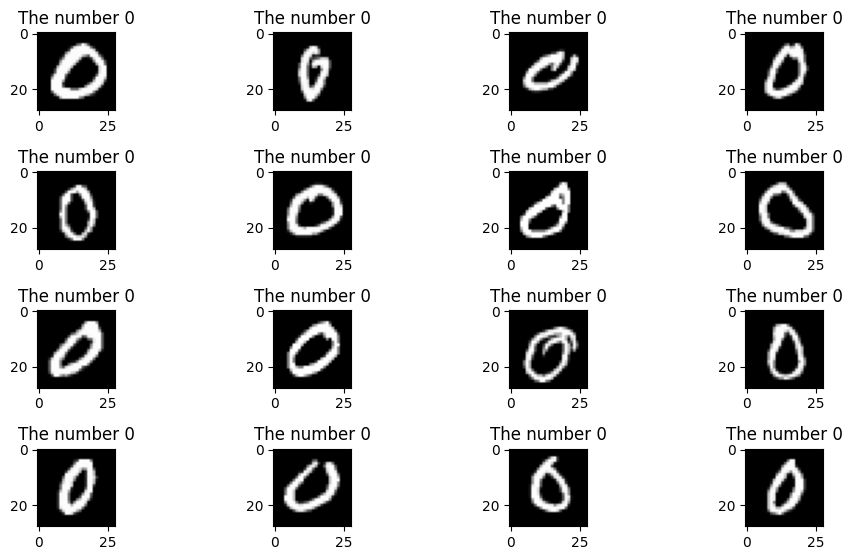

In [8]:
plotSample(0)

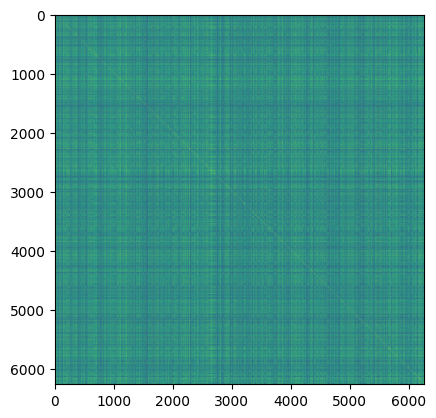

In [9]:
# Find out how similar the images are
digit = 7

data = trainData[np.where(trainLabels == digit)]
label = trainLabels[np.where(trainLabels == digit)]
C = np.corrcoef(data[:,:])
plt.imshow(C)
plt.show()

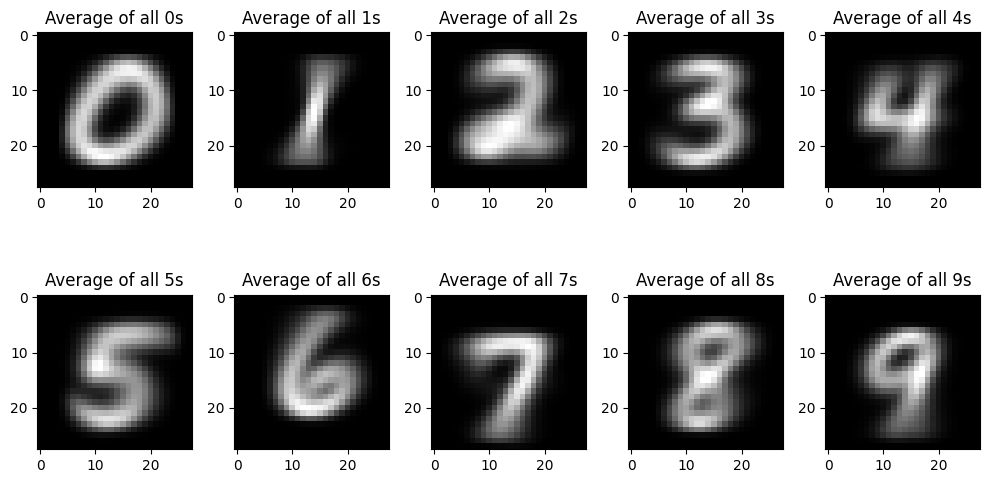

In [10]:
fig, axs = plt.subplots(2, 5, figsize=(10, 6))
for i,ax in enumerate(axs.flatten()):
    data = trainData[np.where(trainLabels == i)]
    label = trainLabels[np.where(trainLabels == i)]
    
    ax.imshow(np.reshape(np.mean(data, axis=0), (28, 28)), cmap='gray')
    ax.set_title(f'Average of all {i}s')

plt.tight_layout(rect=[0,0,1,.95])
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<p>We will use log-softmax to activate the output layer, as it penalizes small probabilities more. It is more suitable for when we have a lot of categories.</p>
</div>

In [32]:
testData = np.loadtxt('../../assets/mnist/mnist_test.csv', delimiter=',', dtype=str)
trainData = np.loadtxt('../../assets/mnist/mnist_train.csv', delimiter=',', dtype=str)

dataType = np.long
allData = np.vstack((np.array(trainData[1:,:], dtype=dataType), np.array(testData[1:,:], dtype=dataType)), dtype=dataType)

In [36]:
labels = allData[:,0]
data = allData[:,1:]

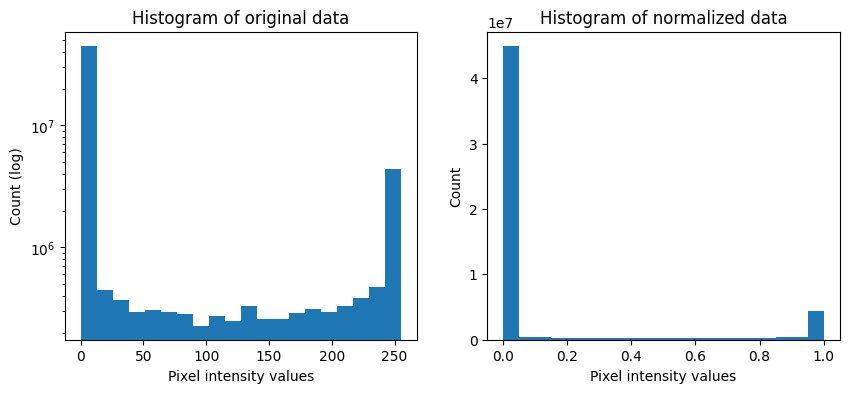

In [47]:
normalizedData = data / np.max(data)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(data.flatten(), 20)
ax[0].set_xlabel('Pixel intensity values')
ax[0].set_ylabel('Count (log)')
ax[0].set_title('Histogram of original data')
ax[0].set_yscale('log')

ax[1].hist(normalizedData.flatten(), 20)
ax[1].set_xlabel('Pixel intensity values')
ax[1].set_ylabel('Count')
ax[1].set_title('Histogram of normalized data')

plt.show()

In [ ]:
dataTensor = torch.tensor(normalizedData).float()
labelsTensor = torch.tensor(labels).long()

trainData, testData, trainLabels, testLabels = train_test_split(dataTensor, labelsTensor, test_size=0.1)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

batchSize = 32
trainLoader = DataLoader(trainData, batch_size=batchSize, shuffle=True, drop_last=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0])

In [86]:
class MNISTnet(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(784, 64)

        self.hiddenLayers = [
            nn.Linear(64, 32),
            nn.Linear(32, 32)
        ]

        self.output = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.input(x))
        for layer in self.hiddenLayers:
            x = F.relu(layer(x))
        return torch.log_softmax(self.output(x), axis=1)

def createModel():
    model = MNISTnet()
    lossfun = nn.NLLLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    return model, lossfun, optimizer

def createAndTrainModel():
    model, lossfun, optimizer = createModel()
    numberOfEpochs = 100

    losses = torch.zeros(numberOfEpochs)
    trainAccuracy = []
    testAccuracy = []

    for epoch in range(numberOfEpochs):
        if epoch % 5 == 0:
            print(f'{epoch=}')
        batchAccuracy = []
        batchLoss = []
        for x,y in trainLoader:
            yHat = model(x)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())

            matches = torch.argmax(yHat,axis=1) == y # booleans
            matchesFloat = matches.float()
            accuracy = 100 * torch.mean(matchesFloat)
            batchAccuracy.append(accuracy)
        
        trainAccuracy.append(np.mean(batchAccuracy))
        losses[epoch] = np.mean(batchLoss)

        x,y = next(iter(testLoader))
        yHat = model(x)

        testAccuracy.append(100*torch.mean((torch.argmax(yHat,axis=1) == y).float()))
    
    return model, trainAccuracy, testAccuracy, losses



In [87]:
model, trainAccuracy, testAccuracy, losses = createAndTrainModel()

epoch=0
epoch=5
epoch=10
epoch=15
epoch=20
epoch=25
epoch=30
epoch=35
epoch=40
epoch=45
epoch=50
epoch=55
epoch=60
epoch=65
epoch=70
epoch=75
epoch=80
epoch=85
epoch=90
epoch=95


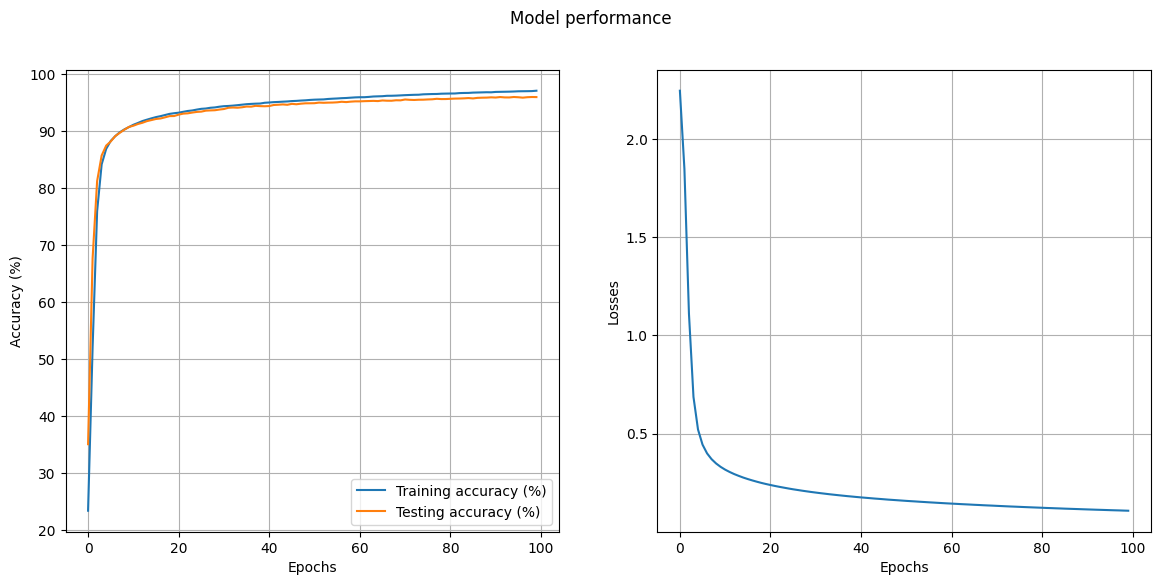

In [88]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(trainAccuracy)
ax[0].plot(testAccuracy)
ax[0].legend(['Training accuracy (%)', 'Testing accuracy (%)'])
ax[0].set_ylabel('Accuracy (%)')
ax[0].set_xlabel('Epochs')
ax[0].grid()

ax[1].plot(losses)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Losses')
ax[1].grid()

plt.suptitle('Model performance')
plt.show()

In [ ]:
x,y = next(iter(testLoader))
predictions = model(x)
predictions

tensor([[-5.4684e+00, -2.2252e+00, -2.6835e+00,  ..., -8.8339e+00,
         -1.0230e+00, -8.8342e+00],
        [-8.9168e+00, -1.2756e+01, -7.6359e+00,  ..., -1.8001e+01,
         -1.3204e+01, -1.5100e+01],
        [-6.4094e+00, -2.5428e-01, -4.4889e+00,  ..., -3.0228e+00,
         -1.9629e+00, -5.9986e+00],
        ...,
        [-1.6970e+01, -1.3617e+01, -1.0354e+01,  ..., -7.8290e-04,
         -1.2133e+01, -7.3746e+00],
        [-1.2064e+01, -1.6016e-03, -8.1827e+00,  ..., -7.9546e+00,
         -7.3022e+00, -1.1827e+01],
        [-1.6491e+01, -9.1553e+00, -7.6908e-03,  ..., -1.6964e+01,
         -4.9164e+00, -1.9850e+01]], grad_fn=<LogSoftmaxBackward0>)

C:\Users\szala\AppData\Local\Temp\ipykernel_3508\1521219392.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[2].bar(range(10), np.exp(sample.detach()))


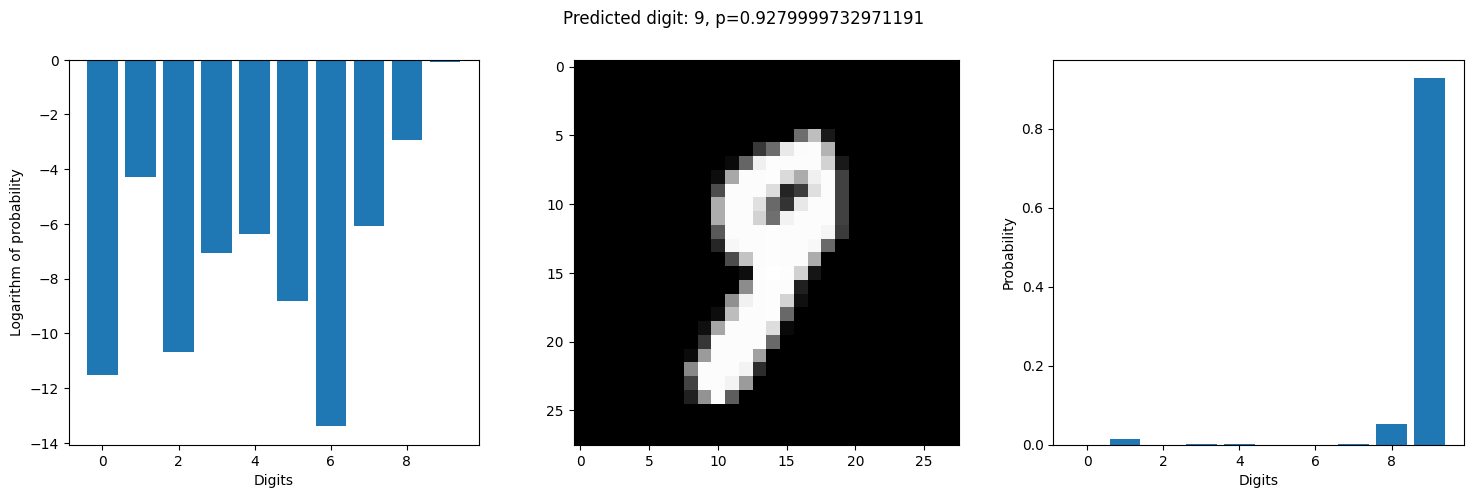

In [138]:
def plotRandomSample():
    randomSample = np.random.randint(0, predictions.shape[0])
    sample = predictions[randomSample]
    sampleData = x[randomSample]

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].bar(range(10), sample.detach())
    ax[0].set_xlabel('Digits')
    ax[0].set_ylabel('Logarithm of probability')

    ax[1].imshow(np.reshape(sampleData.detach().numpy(), (28, 28)), cmap='gray')

    ax[2].bar(range(10), np.exp(sample.detach()))
    ax[2].set_xlabel('Digits')
    ax[2].set_ylabel('Probability')

    plt.suptitle(f'Predicted digit: {np.argmax(np.exp(sample.detach().numpy()))}, p={np.round((np.max(np.exp(sample.detach().numpy()))), 4)}')

    plt.show()

plotRandomSample()

C:\Users\szala\AppData\Local\Temp\ipykernel_3508\1521219392.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[2].bar(range(10), np.exp(sample.detach()))


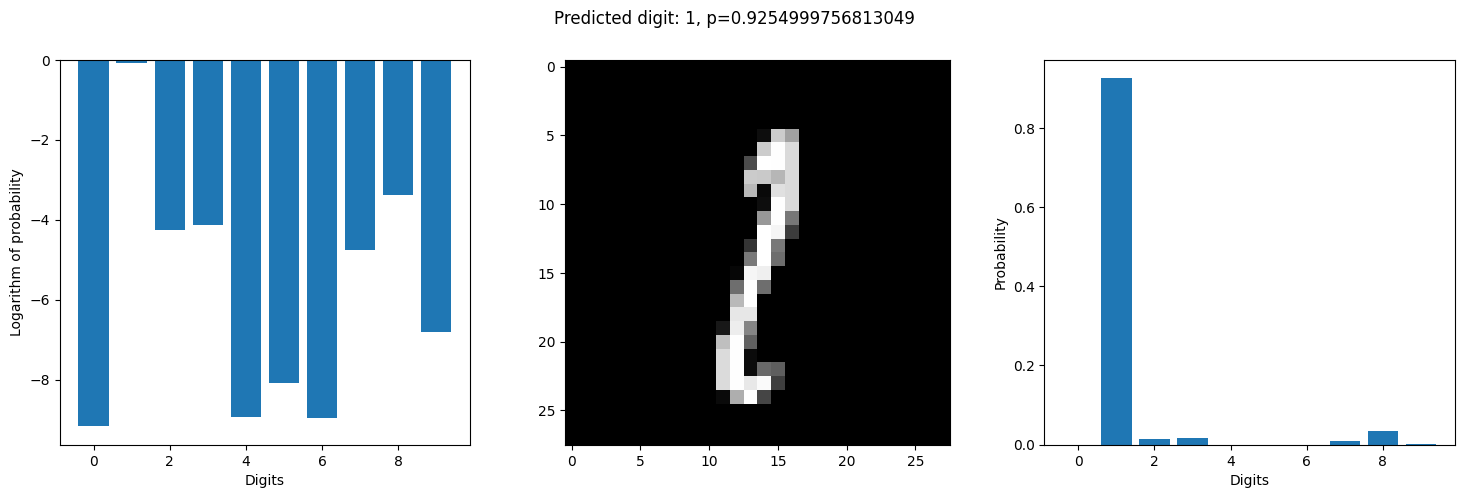

In [139]:
plotRandomSample()